In [2]:
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print(os.getcwd()), print(os.listdir('/content/drive/MyDrive'))

In [ ]:
dataframes = []

path = '../data'
files = glob.glob(os.path.join(path, '*.csv'))
print(len(files))

# READ FILES
for f in files:

    # READ CONTENT USING PANDAS
    temp_file = pd.read_csv(f, skiprows=3)

    # EXTRACT CAPACITY
    basename = os.path.basename(f).replace('.csv', '')

    match = re.search(r'^(\d+)2[0-4][bwty]*$', basename)

    capacity = int(match.group(1)) if match else 0

    # INSERT CAPACITY_KW COLUMN
    temp_file.insert(1, 'capacity (kW)', int(capacity))

    # DROP LOCAL TIME
    temp_file = temp_file.drop('local_time', axis=1)

    # CONVERT TIME TO PROPER DATETIME
    temp_file['time'] = pd.to_datetime(temp_file['time'])

    # RENAME ELECTRICITY COL TO GENERATION
    temp_file.rename(columns={'electricity':'generation (kW)'}, inplace=True)

    # APPEND TO DATAFRAMES
    dataframes.append(temp_file)

print(len(dataframes))

combine_data = pd.concat(dataframes, ignore_index=True)
print(len(combine_data))
print(combine_data.tail()), print(combine_data.dtypes)

In [ ]:
combine_data.to_csv('../data/new_data/Renergy.csv', index=False)

In [6]:
ds = pd.read_csv('/content/drive/MyDrive/data/Renergy.csv', index_col=False)

ds.dtypes

,0
time,object
capacity (kW),int64
generation (kW),float64
irradiance_direct,float64
irradiance_diffuse,float64
temperature,float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(ds.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation b/n features')
plt.show()

In [ ]:
plot_data = ds.drop(['time'], axis=1)

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
sns.barplot(x=plot_data['capactiy (kW)'], y=plot_data['generation (kW)'], hue=plot_data['capacity (kW)'], data=plot_data, palette='viridis')
plt.title('plot of features')

plt.subplot(1, 2, 2)
sns.barplot(x=plot_data['temperature'], y=plot_data['generation (kW)'], data=plot_data[:24], hue=plot_data['temperature'], palette='viridis')

plt.tight_layout()
plt.show()

In [7]:
# print(list(ds.columns))
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# print(ds.head())

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(ds.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation b/n features')
plt.show()

In [17]:
ds['time'] = pd.to_datetime(ds['time'])

ds['hour'] = ds['time'].dt.hour
ds['month'] = ds['time'].dt.month
ds['dayofyear'] = ds['time'].dt.dayofyear
ds['dayofweek'] = ds['time'].dt.dayofweek


ds['hour_sin'], ds['hour_cos'] = np.sin(2*np.pi * ds['hour']/24), np.cos(2*np.pi*ds['hour']/24)
ds['month_sin'], ds['month_cos'] = np.sin(2*np.pi*ds['month']/12), np.cos(2*np.pi*ds['month']/12)
ds['dayofyear_sin'], ds['dayofyear_cos'] = np.sin(2*np.pi*ds['dayofyear']/365), np.cos(2*np.pi*ds['dayofyear']/365)
ds['dayofweek_sin'], ds['dayofweek_cos'] = np.sin(2*np.pi*ds['dayofweek']/7), np.cos(2*np.pi*ds['dayofweek']/7)

ds['isdaylight'] = ((ds['hour'] >=6) & (ds['hour'] <=18)).astype(int)

ds['gen_lag1'] = ds['generation (kW)'].shift(1)
ds['gen_lag24'] = ds['generation (kW)'].shift(24)

print([item for item in zip(ds['hour'], ds['isdaylight'])][:40])
dst = ds.drop(['time', 'hour', 'month', 'dayofyear', 'dayofweek'], axis=1)
dst.dropna(inplace=True)
print(dst.head())



[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 0), (20, 0), (21, 0), (22, 0), (23, 0), (0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1)]
    capacity (kW)  generation (kW)  irradiance_direct  irradiance_diffuse  \
24         100000              0.0                0.0                 0.0   
25         100000              0.0                0.0                 0.0   
26         100000              0.0                0.0                 0.0   
27         100000              0.0                0.0                 0.0   
28         100000              0.0                0.0                 0.0   

    temperature  hour_sin  hour_cos  month_sin  month_cos  dayofyear_sin  \
24       24.461  0.000000  1.000000        0.5   0.866025       0.034422   
25       23.813  0.258819  0.965926        0

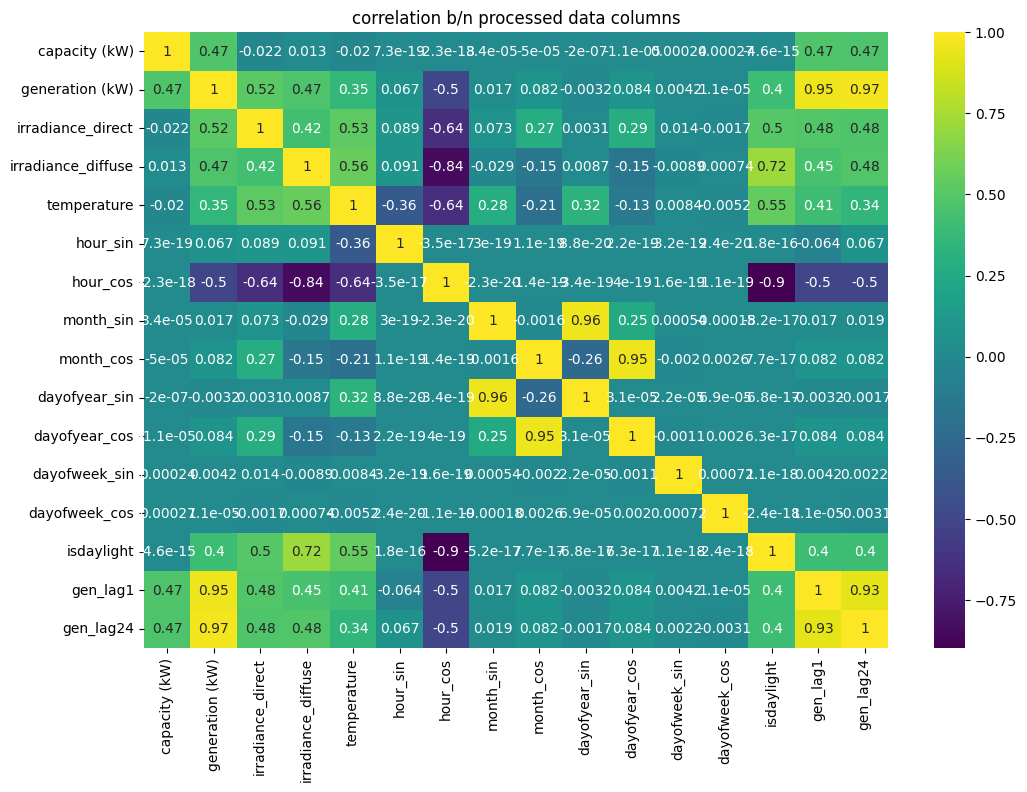

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(dst.corr(), annot=True, cmap='viridis')
plt.title('correlation b/n processed data columns')
plt.show()

In [18]:
dst.to_csv('/content/drive/MyDrive/data/ProcessedRenergy.csv', index=False)

In [20]:
dst = pd.read_csv('/content/drive/MyDrive/data/ProcessedRenergy.csv')

In [21]:
print(list(dst.columns))

['capacity (kW)', 'generation (kW)', 'irradiance_direct', 'irradiance_diffuse', 'temperature', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'dayofweek_sin', 'dayofweek_cos', 'isdaylight', 'gen_lag1', 'gen_lag24']


In [22]:
features_dynamic = [
    'temperature',
    'capacity (kW)',
    'irradiance_direct',
    'irradiance_diffuse',
    'irradiance_direct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'dayofweek_sin',
    'dayofweek_cos',
    'dayofyear_sin',
    'dayofyear_cos',
    'isdaylight',
    'gen_lag1',
    'gen_lag24'
]

features_static = [
    'temperature',
    'capacity (kW)',
    'irradiance_direct',
    'irradiance_diffuse',
    'irradiance_direct',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'dayofweek_sin',
    'dayofweek_cos',
    'dayofyear_sin',
    'dayofyear_cos',
    'isdaylight',
]

Xd = dst[features_dynamic].astype('Float32')
Xs = dst[features_static].astype('Float32')
y = dst['generation (kW)'].astype('float32')

index = int(len(dst)*0.8)

Xd_train, Xd_test = Xd[:index], Xd[index:]
Xs_train, Xs_test = Xs[:index], Xs[index:]
y_train, y_test = y[:index], y[index:]

print(list(Xd.columns)), print(list(Xs.columns))
print(len(y)), print(len(y_train)), print(len(y_test)), print(len(Xd_train)), print(len(Xd_test))

['temperature', 'capacity (kW)', 'irradiance_direct', 'irradiance_diffuse', 'irradiance_direct', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'isdaylight', 'gen_lag1', 'gen_lag24']
['temperature', 'capacity (kW)', 'irradiance_direct', 'irradiance_diffuse', 'irradiance_direct', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'isdaylight']
648816
519052
129764
519052
129764


(None, None, None, None, None)

In [23]:
scaler_dyn = StandardScaler()
scaler_stat = StandardScaler()

scaler_dyn.fit(Xd_train)
scaler_stat.fit(Xs_train)

Xd_train_scaled, Xd_test_scaled = scaler_dyn.transform(Xd_train), scaler_dyn.transform(Xd_test)
Xs_train_scaled, Xs_test_scaled = scaler_stat.transform(Xs_train), scaler_stat.transform(Xs_test)

In [ ]:

params_config = {
    'model1': {'n_estimators': [100, 200, 300], 
           'max_depth': [10, 15, 20, None], 
           'criterion': ['squared_error', 'friedman_mse', 'poisson'], 
           'max_features': ['sqrt', 'log2']
           },
    'model2': {'hidden_layer_sizes': [(100,), (100, 50), (50, 25)],
            'alpha': [0.0001, 0.05],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': [0.001, 0.01]
            },
    'model3': {
            'n_estimators': [100, 300, 500],
            'learning_rate': [0.05, 0.1],
            'max_depth': [6, 10, 15],
            'subsample': [0.8, 1.0]
            }
}

basemodels = {'model1': RandomForestRegressor(random_state=42), 
              'model2': MLPRegressor(max_iter=1200, random_state=42), 
              'model3': XGBRegressor(n_jobs=1, random_state=42)
}

def best_param_grid_search(models, all_params, X, y):
    best_params_results = {}

    for name, model in models.items():

        params = all_params[name]

        search = GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1)
        search.fit(X, y)
        
        print(f'{name}: {search.best_params_}')

        best_params_results[name] = search.best_params_

    return best_params_results

X_sample, _, y_sample, _ = train_test_split(Xd_train_scaled, y_train, train_size=5000, random_state=42)

best_params = best_param_grid_search(basemodels, params_config, X_sample, y_sample)

In [ ]:
# MODEL DEFINITION

model_rf = RandomForestRegressor(**best_params['model1'], random_state=42)
model_xgb = XGBRegressor(**best_params['model3'], random_state=42)
model_ml = MLPRegressor(**best_params['model2'], max_iter=1000, random_state=42)

stack_dynamic_rg = StackingRegressor(
    estimators=[
        ('rf', model_rf),
        ('ml', model_ml),
        ('xgb', model_xgb)
    ],
    final_estimator=ExtraTreesRegressor(n_estimators=300, criterion='squared_error', random_state=42),
    n_jobs=-1,
    cv=5
)

print('Stack training is underway')

stack_dynamic_rg.fit(Xd_train_scaled, y_train)

In [ ]:
# SAVE MODEL
import joblib

joblib.dump(stack_dynamic_rg, '/content/drive/MyDrive/models/saved_stack_model_dynamic.joblib', compress=3)
joblib.dump(scaler_dyn, '/content/drive/MyDrive//models/features_scaler_dynamic.joblib')
print('files successfully saved')

In [ ]:
#PREDICTIONS

y_preds_dyn = stack_dynamic_rg.predict(Xd_test_scaled)

In [ ]:
print(f'mean_absolute_error of model is\n:{mean_absolute_error(y_test, y_preds_dyn):.2f}')
print(f'R2_score of model is: \n {r2_score(y_test, y_preds_dyn):.2f}')
print(f'root_mean_squared_error of model is: \n {root_mean_squared_error(y_test, y_preds_dyn):.2f}')

In [ ]:
## Doing static prediction with static model

In [ ]:

params_config = {
    'model1': {'n_estimators': [100, 200], 
           'max_depth': [10, 15, None], 
           'criterion': ['squared_error', 'friedman_mse', 'poisson'], 
           'max_features': ['sqrt', 'log2']
           },
    'model2': {'hidden_layer_sizes': [(100,), (100, 50), (50, 25)],
            'alpha': [0.0001, 0.05],
            'activation': ['relu', 'tanh'],
            'learning_rate_init': [0.001, 0.01]
            },
    'model3': {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'max_depth': [6, 10, 15],
            'subsample': [0.8, 1.0]
            }
}

basemodels = {'model1': RandomForestRegressor(), 
              'model2': MLPRegressor(max_iter=200), 
              'model3': XGBRegressor(n_jobs=1)
}

def best_param_grid_search(models, all_params, X, y):
    best_params_results = {}

    for name, model in models.items():

        params = all_params[name]

        search = GridSearchCV(estimator=model, param_grid=params, cv=5, n_jobs=-1)
        search.fit(X, y)
        
        print(f'{name}: {search.best_params_}')

        best_params_results[name] = search.best_params_

    return best_params_results

X_sample, _, y_sample, _ = train_test_split(Xs_train_scaled, y_train, train_size=1500, random_state=42)

best_params = best_param_grid_search(basemodels, params_config, X_sample, y_sample)

In [ ]:
# MODEL DEFINITION

model_rf = RandomForestRegressor(**best_params['model1'])
model_xgb = XGBRegressor(**best_params['model3'])
model_ml = MLPRegressor(**best_params['model2'])

stack_static_rg = StackingRegressor(
    estimators=[
        ('rf', model_rf),
        ('ml', model_ml),
        ('xgb', model_xgb)
    ],
    final_estimator=ExtraTreesRegressor(n_estimators=100),
    n_jobs=-1,
    cv=5
)

print('Stack training is underway')

stack_static_rg.fit(Xs_train_scaled, y_train)

In [ ]:
# SAVE MODEL
import joblib

joblib.dump(stack_static_rg, '/content/drive/MyDrive//models/saved_stack_model_static.joblib', compress=3)
joblib.dump(scaler_stat, '/content/drive/MyDrive/models/features_scaler_static.joblib')
print('files successfully saved')

In [ ]:
y_preds_stat = stack_static_rg.predict(Xs_test_scaled)

In [ ]:
print(f'mean_absolute_error of model is\n:{mean_absolute_error(y_test, y_preds_stat):.2f}')
print(f'R2_score of model is: \n {r2_score(y_test, y_preds_stat):.2f}')
print(f'root_mean_squared_error of model is: \n {root_mean_squared_error(y_test, y_preds_stat):.2f}')